In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
df=pd.read_excel('bank_data.xlsx')
df

,CustomerID,Age,Gender,Income,Balance,Transactions,CreditScore,Loan,Region,Tenure,IsActive
0,1,44,Male,2198,25518.0,61,NaN,No,South,3,No
1,2,30,Female,5158,28068.0,96,841.0,No,East,7,Yes
2,3,20,Female,747,43922.0,10,613.0,No,South,9,Yes
3,4,28,Male,2279,47635.0,53,NaN,Yes,North,13,Yes
4,5,61,Female,2360,25105.0,102,830.0,No,West,9,Yes
...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,35,Female,5708,36671.0,51,777.0,Yes,East,17,No
9996,9997,34,Male,9162,37419.0,68,713.0,Yes,West,2,Yes
9997,9998,34,Female,8321,41633.0,80,308.0,No,North,10,Yes
9998,9999,28,Male,6228,28653.0,134,899.0,Yes,South,11,No


In [2]:
# We get information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CustomerID    10000 non-null  int64  
 1   Age           10000 non-null  int64  
 2   Gender        10000 non-null  str    
 3   Income        10000 non-null  int64  
 4   Balance       10000 non-null  float64
 5   Transactions  10000 non-null  int64  
 6   CreditScore   9000 non-null   float64
 7   Loan          10000 non-null  str    
 8   Region        10000 non-null  str    
 9   Tenure        10000 non-null  int64  
 10  IsActive      10000 non-null  str    
dtypes: float64(2), int64(5), str(4)
memory usage: 859.5 KB


In [3]:
# Count Rows 
df.shape[0]

10000

In [4]:
# Data Cleaning
# CreditScore missing values fill
df["CreditScore"]=df["CreditScore"].fillna(df["CreditScore"].median())
# Balance outlier removal(IQR)
Q1=df['Balance'].quantile(0.25)
Q3=df['Balance'].quantile(0.75)
IQR=Q3-Q1
loweroutlier=Q1-1.5*IQR
upperoutlier=Q3+1.5*IQR
data=df[(df['Balance']>=loweroutlier)&(df['Balance']<=upperoutlier)]

In [5]:
data.info()

<class 'pandas.DataFrame'>
Index: 9500 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CustomerID    9500 non-null   int64  
 1   Age           9500 non-null   int64  
 2   Gender        9500 non-null   str    
 3   Income        9500 non-null   int64  
 4   Balance       9500 non-null   float64
 5   Transactions  9500 non-null   int64  
 6   CreditScore   9500 non-null   float64
 7   Loan          9500 non-null   str    
 8   Region        9500 non-null   str    
 9   Tenure        9500 non-null   int64  
 10  IsActive      9500 non-null   str    
dtypes: float64(2), int64(5), str(4)
memory usage: 890.6 KB


In [6]:
# Average Age
int(data['Age'].mean())

46

In [7]:
# Gender counts
data['Gender'].value_counts()

Gender
Female    4777
Male      4723
Name: count, dtype: int64

In [8]:
# Number of customers by region
data['Region'].value_counts()

Region
West     2450
North    2370
South    2340
East     2340
Name: count, dtype: int64

In [9]:
# Average Balance
round(data['Balance'].mean(),3)

np.float64(24785.175)

In [10]:
# Active vs Inactive
data['IsActive'].value_counts()

IsActive
Yes    4774
No     4726
Name: count, dtype: int64

In [11]:
# Top 10 customers with the highest balance
data.sort_values(by='Balance',ascending=False).head(10)

,CustomerID,Age,Gender,Income,Balance,Transactions,CreditScore,Loan,Region,Tenure,IsActive
3120,3121,22,Female,3541,49996.0,30,419.0,Yes,East,12,Yes
766,767,29,Female,3796,49995.0,157,427.0,No,East,15,No
2362,2363,43,Female,8904,49987.0,172,787.0,Yes,South,14,No
2355,2356,51,Female,7355,49982.0,200,676.0,No,South,9,No
2840,2841,38,Male,7341,49976.0,87,605.0,Yes,West,11,No
335,336,41,Female,5503,49972.0,77,598.0,Yes,East,3,Yes
2094,2095,30,Female,2931,49969.0,165,796.0,No,East,18,Yes
4087,4088,34,Male,1117,49969.0,32,853.0,No,North,17,Yes
9360,9361,70,Male,1742,49955.0,164,482.0,Yes,East,18,Yes
3385,3386,45,Female,8016,49952.0,170,781.0,Yes,West,3,No


In [12]:
# Average age by gender and activity status
data.groupby(['Gender','IsActive'])["Age"].mean()

Gender  IsActive
Female  No          47.031884
        Yes         46.556732
Male    No          46.264388
        Yes         46.390962
Name: Age, dtype: float64

In [13]:
# Average age by Region
data.groupby("Region")["Balance"].mean()

Region
East     25095.880769
North    24578.822363
South    24679.938462
West     24788.545714
Name: Balance, dtype: float64

In [14]:
# Average age by Region and Gender
data.groupby(["Region","Gender"])["Balance"].mean()

Region  Gender
East    Female    25237.394281
        Male      24958.185497
North   Female    24476.630952
        Male      24679.473199
South   Female    24551.999171
        Male      24816.233892
West    Female    23946.211290
        Male      25651.764463
Name: Balance, dtype: float64

In [15]:
# Income quartile analysis
data["Income"].quantile([0.25,0.5,0.75])

0.25    2892.00
0.50    5330.00
0.75    7669.25
Name: Income, dtype: float64

In [16]:
# Customer segmentation
def segment(income):
    if income<2000:
        return 'Low'
    elif income<=5000:
        return 'Middle'
    else:
        return 'High'
data['SegmentWithIncome']=data['Income'].apply(segment)
data['SegmentWithIncome'].value_counts()

SegmentWithIncome
High      5090
Middle    2957
Low       1453
Name: count, dtype: int64

In [17]:
# Suspicious activity
suspicious=data[(data['Transactions']>100) & (data['Balance']<1000)]
suspicious

,CustomerID,Age,Gender,Income,Balance,Transactions,CreditScore,Loan,Region,Tenure,IsActive,SegmentWithIncome
101,102,36,Female,5138,882.0,108,598.0,Yes,North,11,Yes,High
107,108,32,Female,5308,602.0,185,598.0,No,North,4,No,High
147,148,43,Female,8427,267.0,132,893.0,Yes,North,19,No,High
260,261,67,Female,4341,976.0,114,364.0,No,West,19,No,Middle
288,289,72,Female,4827,779.0,181,438.0,No,West,7,Yes,Middle
...,...,...,...,...,...,...,...,...,...,...,...,...
9738,9739,59,Male,8060,807.0,192,894.0,No,East,20,Yes,High
9770,9771,74,Female,8833,75.0,181,352.0,No,North,20,No,High
9775,9776,60,Male,8169,689.0,142,816.0,No,East,13,No,High
9811,9812,61,Female,1476,474.0,189,393.0,No,South,6,Yes,Low


In [18]:
# Shows the percentage of people with a loan.
loanrate=(data['Loan']=='Yes').mean()*100
print(f"{loanrate:.2f}%")

50.12%


In [19]:
# Income Range
bins=[0, 2000, 4000, 6000, 10000]
labels=['0-2K', '2K-4K', '4K-6K','6K-10K']
data['IncomeRange']=pd.cut(data['Income'],bins=bins,labels=labels)
result=data['IncomeRange'].value_counts()
print(result)
data

IncomeRange
6K-10K    4060
4K-6K     2003
2K-4K     1982
0-2K      1455
Name: count, dtype: int64


,CustomerID,Age,Gender,Income,Balance,Transactions,CreditScore,Loan,Region,Tenure,IsActive,SegmentWithIncome,IncomeRange
0,1,44,Male,2198,25518.0,61,598.0,No,South,3,No,Middle,2K-4K
1,2,30,Female,5158,28068.0,96,841.0,No,East,7,Yes,High,4K-6K
2,3,20,Female,747,43922.0,10,613.0,No,South,9,Yes,Low,0-2K
3,4,28,Male,2279,47635.0,53,598.0,Yes,North,13,Yes,Middle,2K-4K
4,5,61,Female,2360,25105.0,102,830.0,No,West,9,Yes,Middle,2K-4K
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,35,Female,5708,36671.0,51,777.0,Yes,East,17,No,High,4K-6K
9996,9997,34,Male,9162,37419.0,68,713.0,Yes,West,2,Yes,High,6K-10K
9997,9998,34,Female,8321,41633.0,80,308.0,No,North,10,Yes,High,6K-10K
9998,9999,28,Male,6228,28653.0,134,899.0,Yes,South,11,No,High,6K-10K


In [20]:
# Detect anomalies: Customer with low balance but high transactions or high balance but low transactions 
lowbalance=data['Balance'].quantile(0.1)
hightransaction=data['Transactions'].quantile(0.9)
highbalance=data['Balance'].quantile(0.9)
lowtransaction=data['Transactions'].quantile(0.1)
cond1=(data['Balance']<lowbalance)&(data['Transactions']>hightransaction)
cond2=(data['Balance'] > highbalance)&(data['Transactions']<lowtransaction)
anomalies=data[cond1|cond2]
data['Anomaly']='Normal'
data.loc[cond1,'Anomaly']='LowBalance_HighTrans'
data.loc[cond2,'Anomaly']='HighBalance_LowTrans'
anomalies=data[data['Anomaly']!='Normal']
anomalies

,CustomerID,Age,Gender,Income,Balance,Transactions,CreditScore,Loan,Region,Tenure,IsActive,SegmentWithIncome,IncomeRange,Anomaly
63,64,63,Male,2991,46421.0,7,539.0,Yes,West,9,Yes,Middle,2K-4K,HighBalance_LowTrans
69,70,34,Female,9833,3785.0,197,519.0,Yes,West,1,No,High,6K-10K,LowBalance_HighTrans
107,108,32,Female,5308,602.0,185,598.0,No,North,4,No,High,4K-6K,LowBalance_HighTrans
174,175,58,Female,4251,2348.0,199,583.0,Yes,West,13,No,Middle,4K-6K,LowBalance_HighTrans
226,227,50,Female,4529,3468.0,188,871.0,Yes,East,18,No,Middle,4K-6K,LowBalance_HighTrans
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9695,9696,26,Female,4264,543.0,185,530.0,Yes,West,1,No,Middle,4K-6K,LowBalance_HighTrans
9738,9739,59,Male,8060,807.0,192,894.0,No,East,20,Yes,High,6K-10K,LowBalance_HighTrans
9792,9793,72,Male,4713,45961.0,9,510.0,No,South,8,Yes,Middle,4K-6K,HighBalance_LowTrans
9811,9812,61,Female,1476,474.0,189,393.0,No,South,6,Yes,Low,0-2K,LowBalance_HighTrans


In [21]:
# Anomaly data and normal data counts
data['Anomaly'].value_counts()

Anomaly
Normal                  9335
LowBalance_HighTrans      96
HighBalance_LowTrans      69
Name: count, dtype: int64

In [22]:
# Segments with balance and transaction
def segment(row):
    if row['Balance']>highbalance and row['Transactions']>hightransaction:
        return 'VIP Active'
    elif row['Balance']>highbalance:
        return 'Rich Passive'
    elif row['Transactions']>hightransaction:
        return 'LowBalance Active'
    else:
        return 'Regular'
data['SegmentWithBalanceAndTransaction']=data.apply(segment,axis=1)
segmentanalysis=data.groupby('SegmentWithBalanceAndTransaction').agg({
    'Balance':['mean','sum'],
    'Transactions':['mean','count']
})
segmentanalysis


Balance              Transactions      
                                          mean          sum         mean count
SegmentWithBalanceAndTransaction                                              
LowBalance Active                 22163.054591   17863422.0   190.836228   806
Regular                           22263.711131  172410179.0    90.164256  7744
Rich Passive                      47594.996441   40122582.0    92.387900   843
VIP Active                        47317.570093    5062980.0   190.700935   107

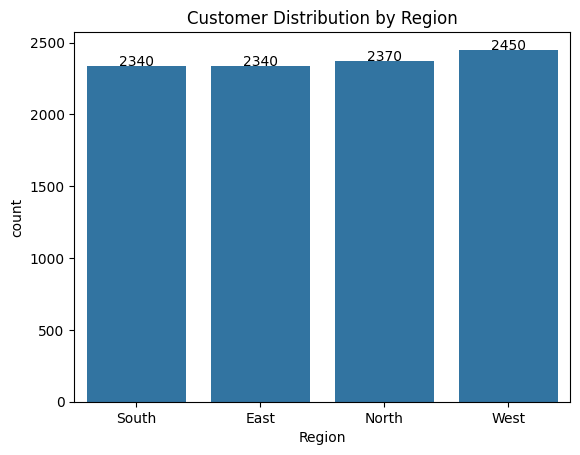

In [23]:
# Number of customers by region
ax=sns.countplot(data=data,x='Region')
for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2,p.get_height(),int(p.get_height()),ha='center')
plt.title('Customer Distribution by Region')
plt.show()

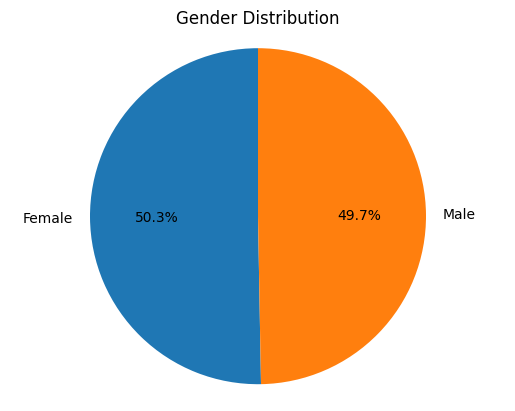

In [24]:
# Number of customers by gender
plt.pie(data['Gender'].value_counts(),labels=data['Gender'].value_counts().index,autopct='%1.1f%%',startangle=90)
plt.title('Gender Distribution')
plt.axis('equal')                 
plt.show()

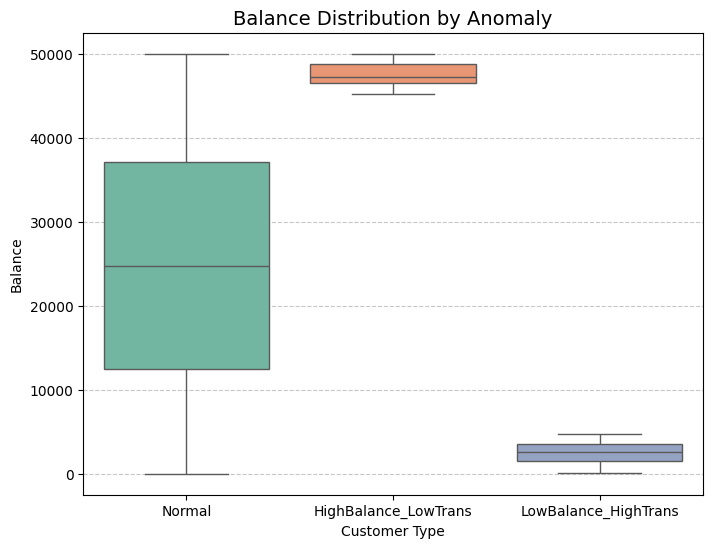

In [25]:
# Balance distribution for anomaly vs normal customers
plt.figure(figsize=(8,6))
sns.boxplot(data=data,x='Anomaly',y='Balance',hue='Anomaly',palette='Set2')
plt.title('Balance Distribution by Anomaly',fontsize=14)
plt.xlabel('Customer Type')
plt.ylabel('Balance')
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()

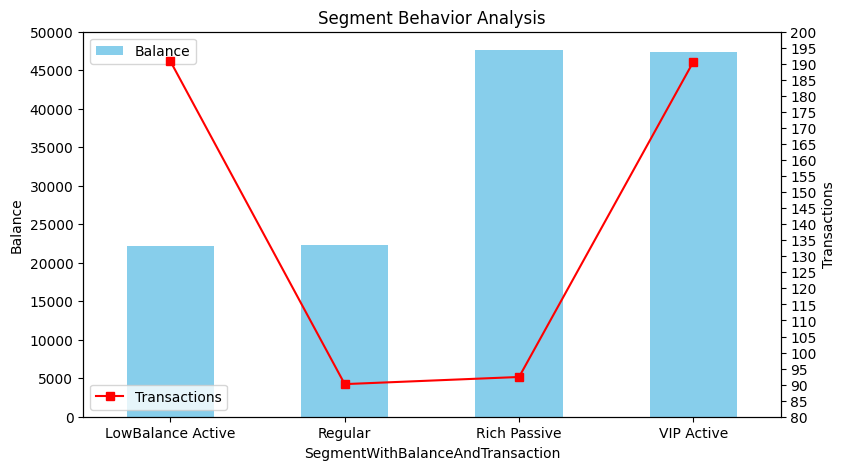

In [37]:
# Customer behavior by balance and transaction segments
plt.figure(figsize=(9,5))
segment_stats=data.groupby('SegmentWithBalanceAndTransaction')[['Balance','Transactions']].mean()
ax=segment_stats['Balance'].plot(kind='bar',color='skyblue',label='Balance')
ax2=ax.twinx()
segment_stats['Transactions'].plot(kind='line',color='red',marker='s',ax=ax2,label='Transactions')
ax.set_title('Segment Behavior Analysis')
ax.set_ylabel('Balance')
ax2.set_ylabel('Transactions')
ax2.set_yticks(range(80,205,5))
ax.set_yticks(range(0,55000,5000))
ax.tick_params(axis='x',rotation=0)
ax.legend()
ax2.legend()
plt.show()

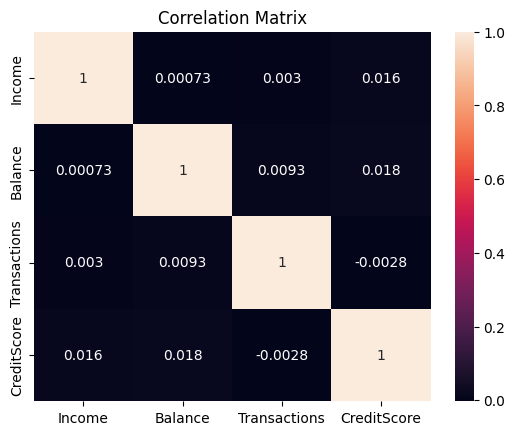

In [27]:
# Correlation between numerical features
corr=data[['Income','Balance','Transactions','CreditScore']].corr()
sns.heatmap(corr,annot=True)
plt.title('Correlation Matrix')
plt.show()

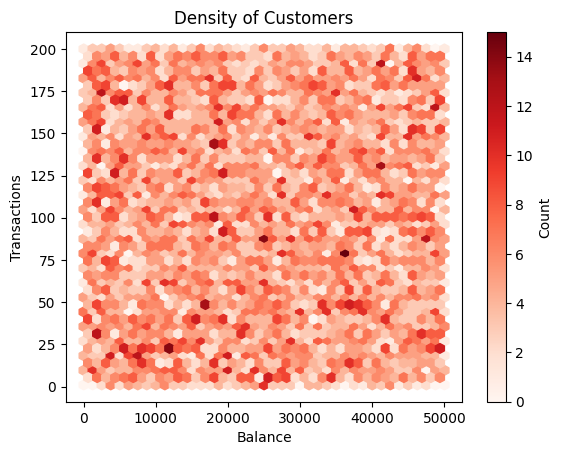

In [28]:
# The density relationship between balance and transactions.
plt.hexbin(data['Balance'],data['Transactions'],gridsize=40,cmap='Reds')
plt.colorbar(label='Count')
plt.xlabel('Balance')
plt.ylabel('Transactions')
plt.title('Density of Customers')
plt.show()

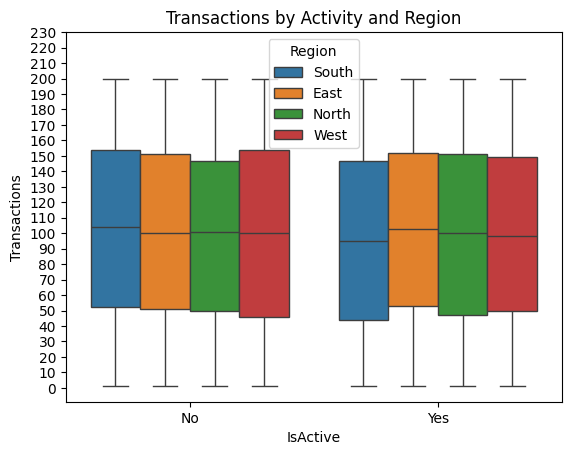

In [29]:
# Transactions by Activity and Region
sns.boxplot(data=data,x='IsActive',y='Transactions',hue='Region')
plt.title('Transactions by Activity and Region')
plt.yticks(range(0,240,10))
plt.show()

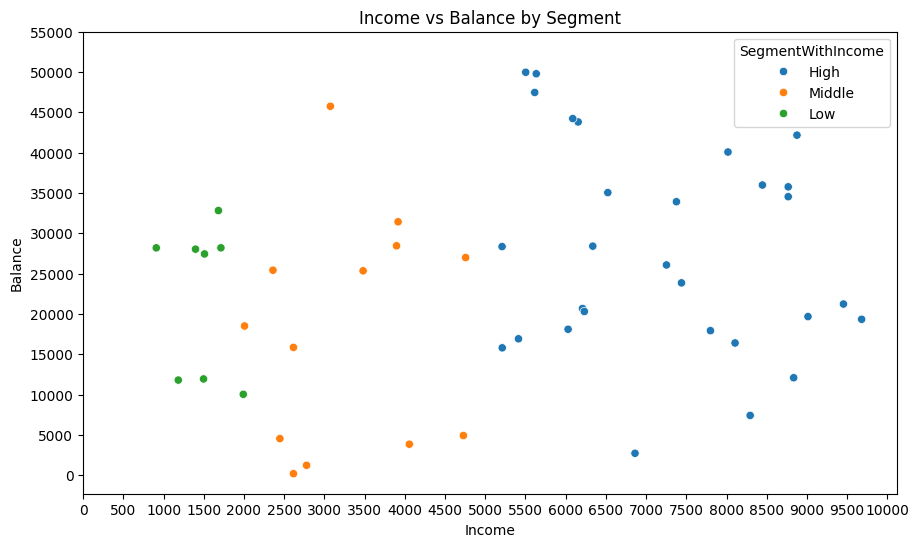

In [30]:
# Income vs Balance by Segment
plt.figure(figsize=(10.5,6))
samplefromdata=data.sample(50)
sns.scatterplot(data=samplefromdata,x='Income',y='Balance',hue='SegmentWithIncome')
plt.title('Income vs Balance by Segment')
plt.yticks(range(0,60000,5000))
plt.xticks(range(0,10500,500))
plt.show()

In [31]:
# Loan Prediction Machine Learning Model
X=data[['Age','Income','Balance','CreditScore']]
y=data['Loan'].map({'Yes':1,'No':0})
X_train,X_test,y_train,y_test=train_test_split(X, y,test_size=0.2)
model=LogisticRegression()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.48368421052631577
